# Exercise 2 - Penicillin 

Cycle 1:
  End time = 12.00 h
  S_end = 0.2289 g/L
  X_end = 29.9313 g/L
  P_end = 17.7032 g/L
  Product removed this cycle = 10.6219 kg

Cycle 2:
  End time = 24.00 h
  S_end = 0.2289 g/L
  X_end = 29.9313 g/L
  P_end = 22.1244 g/L
  Product removed this cycle = 13.2747 kg

Cycle 3:
  End time = 36.00 h
  S_end = 0.2289 g/L
  X_end = 29.9313 g/L
  P_end = 23.2297 g/L
  Product removed this cycle = 13.9378 kg

Cycle 4:
  End time = 48.00 h
  S_end = 0.2289 g/L
  X_end = 29.9313 g/L
  P_end = 23.5061 g/L
  Product removed this cycle = 14.1036 kg

Cycle 5:
  End time = 60.00 h
  S_end = 0.2289 g/L
  X_end = 29.9313 g/L
  P_end = 23.5752 g/L
  Product removed this cycle = 14.1451 kg

Cycle 6:
  End time = 72.00 h
  S_end = 0.2289 g/L
  X_end = 29.9313 g/L
  P_end = 23.5924 g/L
  Product removed this cycle = 14.1555 kg

Cycle 7:
  End time = 84.00 h
  S_end = 0.2289 g/L
  X_end = 29.9313 g/L
  P_end = 23.5967 g/L
  Product removed this cycle = 14.1580 kg

Cycle 8:
  End time = 96.00 h
  S_

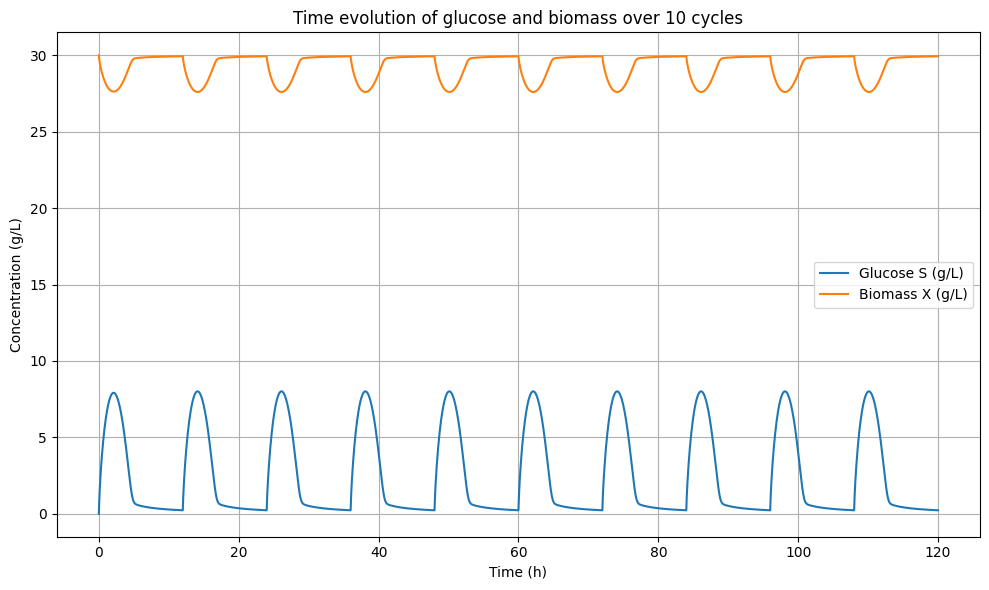

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# Parameters
# ==========================================
mu_m = 0.2       # 1/h
Ks = 0.5         # g/L
Ki = 50.0        # g/L
Yxs = 0.3        # g cells / g glucose
qp = 0.08        # g product / g cells / h

F = 50.0         # L/h
Sf = 100.0       # g/L

V0 = 200.0       # L
Vmax = 800.0     # L
Vwithdraw = 600.0  # L

# Initial conditions
S_init = 0.0     # g/L
X_init = 30.0    # g/L
P_init = 0.0     # g/L

n_cycles = 10

# ==========================================
# Cycle time from volume balance:
# V(t) = V0 + F*t
# cycle ends when V = Vmax
# ==========================================
t_cycle = (Vmax - V0) / F   # = 12 h


# ==========================================
# Growth rate with substrate inhibition
# mu(S) = mu_m * S / (Ks + S + S^2/Ki)
# ==========================================
def mu(S):
    return mu_m * S / (Ks + S + (S**2) / Ki)


# ==========================================
# ODE system for concentrations
# dX/dt = mu(S)*X - (F/V)*X
# dS/dt = (F/V)*(Sf - S) - (1/Yxs)*mu(S)*X
# dP/dt = qp*X - (F/V)*P
#
# Here V(t) = V0 + F*t during each filling phase
# ==========================================
def model(t, y):
    S, X, P = y
    V = V0 + F * t
    dXdt = mu(S) * X - (F / V) * X
    dSdt = (F / V) * (Sf - S) - (1.0 / Yxs) * mu(S) * X
    dPdt = qp * X - (F / V) * P
    return [dSdt, dXdt, dPdt]


# ==========================================
# Simulation over 10 cycles
# ==========================================
S0 = S_init
X0 = X_init
P0 = P_init

time_total = []
S_total = []
X_total = []
P_total = []

product_removed_total_kg = 0.0
time_shift = 0.0

for cycle in range(n_cycles):
    sol = solve_ivp(
        model,
        [0, t_cycle],
        [S0, X0, P0],
        method='RK45',
        max_step=0.05
    )

    t = sol.t + time_shift
    S = sol.y[0]
    X = sol.y[1]
    P = sol.y[2]

    # store solution, avoid duplicate point between cycles
    if cycle == 0:
        time_total.extend(t)
        S_total.extend(S)
        X_total.extend(X)
        P_total.extend(P)
    else:
        time_total.extend(t[1:])
        S_total.extend(S[1:])
        X_total.extend(X[1:])
        P_total.extend(P[1:])

    # concentrations at the end of cycle
    S_end = S[-1]
    X_end = X[-1]
    P_end = P[-1]

    # product removed when 600 L is withdrawn
    # mass removed = concentration * withdrawn volume
    # units: (g/L)*(L) = g  --> kg by dividing by 1000
    product_removed_this_cycle_kg = P_end * Vwithdraw / 1000.0
    product_removed_total_kg += product_removed_this_cycle_kg

    print(f"Cycle {cycle+1}:")
    print(f"  End time = {time_shift + t_cycle:.2f} h")
    print(f"  S_end = {S_end:.4f} g/L")
    print(f"  X_end = {X_end:.4f} g/L")
    print(f"  P_end = {P_end:.4f} g/L")
    print(f"  Product removed this cycle = {product_removed_this_cycle_kg:.4f} kg\n")

    # After withdrawal from a well-mixed reactor,
    # concentrations remain the same, only volume resets to 200 L
    S0 = S_end
    X0 = X_end
    P0 = P_end

    time_shift += t_cycle


# ==========================================
# Final results
# ==========================================
print("====================================")
print(f"Cycle time = {t_cycle:.2f} h")
print(f"Total time for {n_cycles} cycles = {n_cycles * t_cycle:.2f} h")
print(f"Total product removed = {product_removed_total_kg:.4f} kg")
print("====================================")


# ==========================================
# Plot glucose and biomass over 10 cycles
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(time_total, S_total, label='Glucose S (g/L)')
plt.plot(time_total, X_total, label='Biomass X (g/L)')
plt.xlabel('Time (h)')
plt.ylabel('Concentration (g/L)')
plt.title('Time evolution of glucose and biomass over 10 cycles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

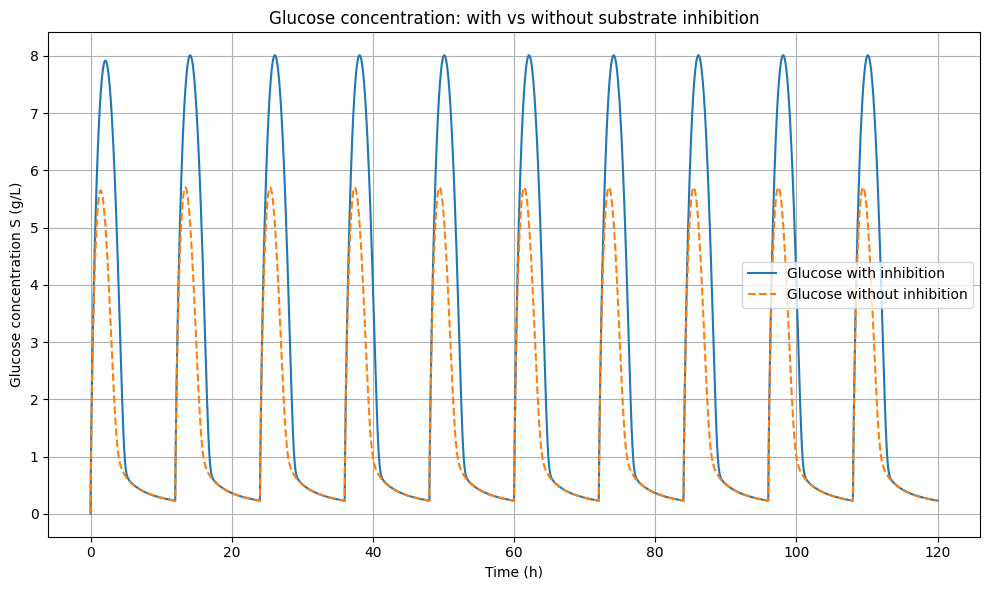

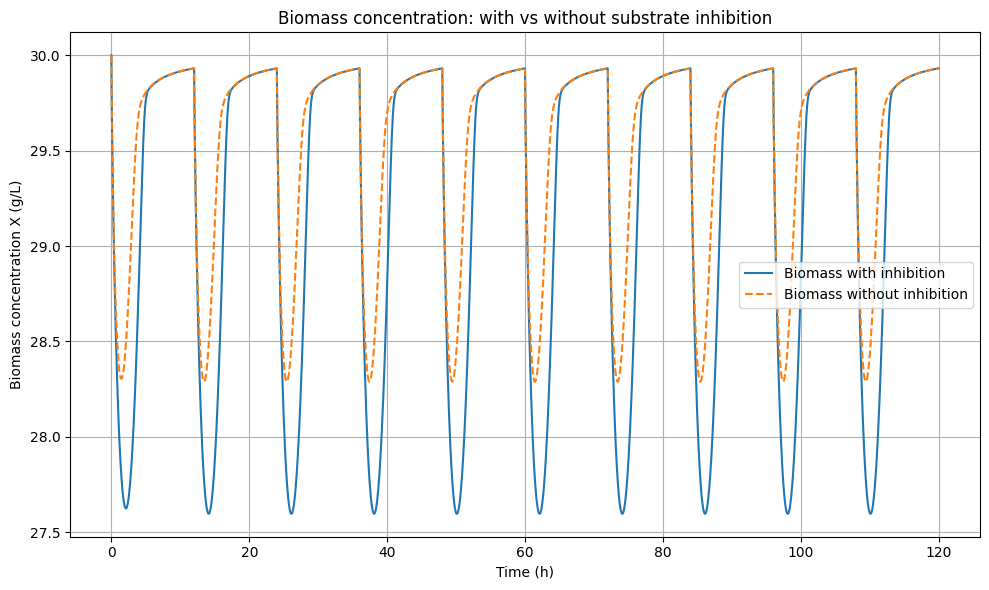

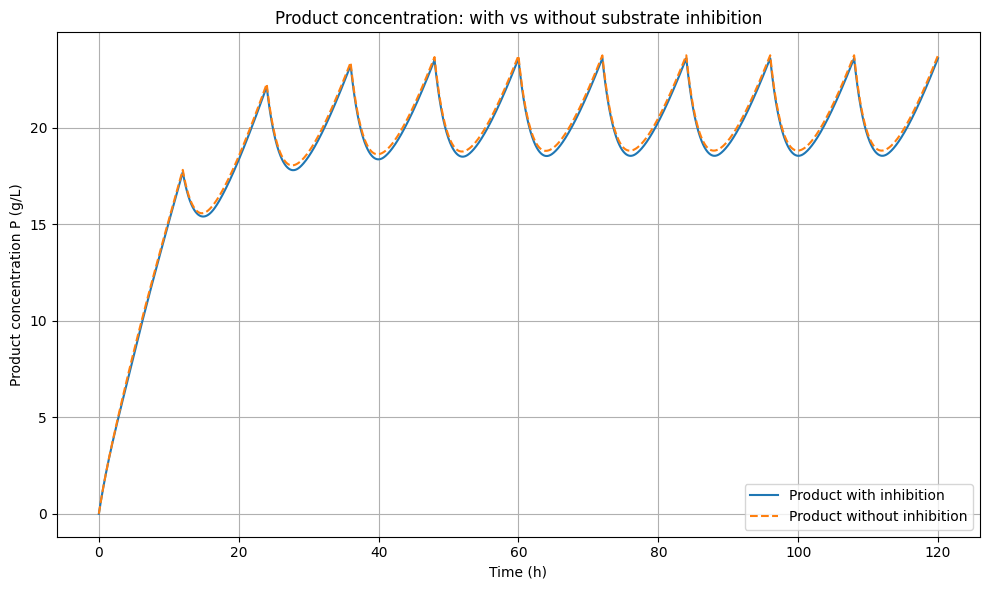

Total product removed with inhibition    = 136.8731 kg
Total product removed without inhibition = 137.7538 kg
Difference                               = 0.8807 kg


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# Parameters
# ==========================================
mu_m = 0.2       # 1/h
Ks = 0.5         # g/L
Ki = 50.0        # g/L
Yxs = 0.3        # g cells / g glucose
qp = 0.08        # g product / g cells / h

F = 50.0         # L/h
Sf = 100.0       # g/L

V0 = 200.0       # L
Vmax = 800.0     # L
Vwithdraw = 600.0  # L

S_init = 0.0     # g/L
X_init = 30.0    # g/L
P_init = 0.0     # g/L

n_cycles = 10
t_cycle = (Vmax - V0) / F   # 12 h


# ==========================================
# Growth rates
# ==========================================
def mu_inhibition(S):
    return mu_m * S / (Ks + S + (S**2) / Ki)

def mu_no_inhibition(S):
    return mu_m * S / (Ks + S)


# ==========================================
# General model
# ==========================================
def model(t, y, mu_func):
    S, X, P = y
    V = V0 + F * t
    dXdt = mu_func(S) * X - (F / V) * X
    dSdt = (F / V) * (Sf - S) - (1.0 / Yxs) * mu_func(S) * X
    dPdt = qp * X - (F / V) * P
    return [dSdt, dXdt, dPdt]


# ==========================================
# Function to simulate multiple cycles
# ==========================================
def simulate_system(mu_func, n_cycles):
    S0 = S_init
    X0 = X_init
    P0 = P_init

    time_total = []
    S_total = []
    X_total = []
    P_total = []

    product_removed_total_kg = 0.0
    time_shift = 0.0

    for cycle in range(n_cycles):
        sol = solve_ivp(
            lambda t, y: model(t, y, mu_func),
            [0, t_cycle],
            [S0, X0, P0],
            method='RK45',
            max_step=0.05
        )

        t = sol.t + time_shift
        S = sol.y[0]
        X = sol.y[1]
        P = sol.y[2]

        if cycle == 0:
            time_total.extend(t)
            S_total.extend(S)
            X_total.extend(X)
            P_total.extend(P)
        else:
            time_total.extend(t[1:])
            S_total.extend(S[1:])
            X_total.extend(X[1:])
            P_total.extend(P[1:])

        S_end = S[-1]
        X_end = X[-1]
        P_end = P[-1]

        product_removed_this_cycle_kg = P_end * Vwithdraw / 1000.0
        product_removed_total_kg += product_removed_this_cycle_kg

        # After withdrawal, concentrations stay the same
        S0 = S_end
        X0 = X_end
        P0 = P_end

        time_shift += t_cycle

    return (
        np.array(time_total),
        np.array(S_total),
        np.array(X_total),
        np.array(P_total),
        product_removed_total_kg
    )


# ==========================================
# Run both simulations
# ==========================================
t_inh, S_inh, X_inh, P_inh, prod_inh = simulate_system(mu_inhibition, n_cycles)
t_noinh, S_noinh, X_noinh, P_noinh, prod_noinh = simulate_system(mu_no_inhibition, n_cycles)


# ==========================================
# Plot glucose comparison
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(t_inh, S_inh, label='Glucose with inhibition')
plt.plot(t_noinh, S_noinh, '--', label='Glucose without inhibition')
plt.xlabel('Time (h)')
plt.ylabel('Glucose concentration S (g/L)')
plt.title('Glucose concentration: with vs without substrate inhibition')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# Plot biomass comparison
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(t_inh, X_inh, label='Biomass with inhibition')
plt.plot(t_noinh, X_noinh, '--', label='Biomass without inhibition')
plt.xlabel('Time (h)')
plt.ylabel('Biomass concentration X (g/L)')
plt.title('Biomass concentration: with vs without substrate inhibition')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# Optional: product comparison
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(t_inh, P_inh, label='Product with inhibition')
plt.plot(t_noinh, P_noinh, '--', label='Product without inhibition')
plt.xlabel('Time (h)')
plt.ylabel('Product concentration P (g/L)')
plt.title('Product concentration: with vs without substrate inhibition')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# Print totals
# ==========================================
print(f"Total product removed with inhibition    = {prod_inh:.4f} kg")
print(f"Total product removed without inhibition = {prod_noinh:.4f} kg")
print(f"Difference                               = {prod_noinh - prod_inh:.4f} kg")